In [5]:
import pandas as pd
import json
from dataclasses import dataclass, asdict
from ml_enhance import QuantumFPFileLoader, QuantumFPDatasetBuilder, ConformerAggregator

In [23]:
errors = pd.read_json("../data/QM9/error_batches.json")

with open("../data/QM9/qm9_test.json") as f:
    mapping = pd.DataFrame(json.load(f)["inputs"])

error_smiles = mapping[mapping["id"].isin(errors["Id"])]["smiles"].values

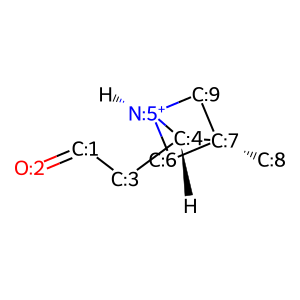

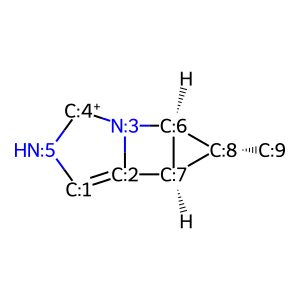

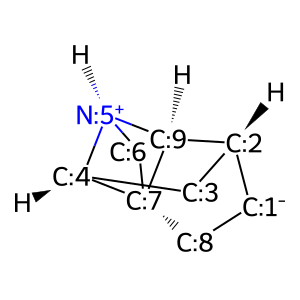

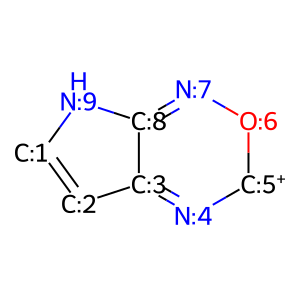

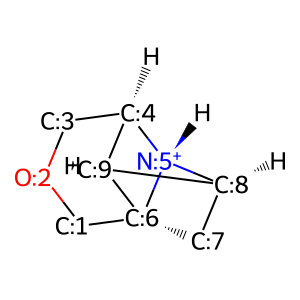

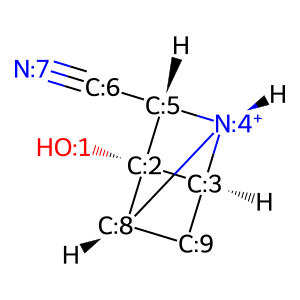

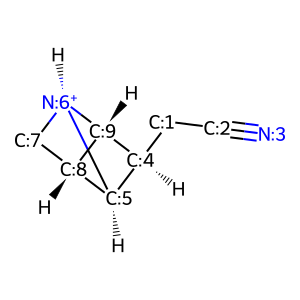

In [34]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

for smiles in error_smiles:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        img = Draw.MolToImage(mol)
        display(img)
    else:
        print(f"Invalid SMILES: {smiles}")

## GFN2-xTB comparison to QM9 values

QM9 is a dataset consisting of about 130k molecules, for which QM properties are calculated on the DFT level of theory. Exact specifications of the level of theory are the following: **B3LYP/6-31G(2df,p)** (hybrid-GGA)

GFN2-xTB is a semi-empirical method that uses a parameterized density functional tight-binding method on the LDA level of theory using a minimal STO-nG basis set. This method also adds a correction to the electron density $\rho$ by accounting for up to the third order variation in the electron density $\delta \rho$.


Some of the molecular properties that are both present in the QM9 dataset and are generated by QuantumFP

|                          | QM9 unit |         QFP unit         |
|:------------------------:|:--------:|:------------------------:|
|   Dipole moment (norm)   |   Debye  |        $e$ $a_0$         |
| Isotropic polarizability |  $a_0^3$ | $e^2$ $a_0^2$ / hartree  |
|       HOMO-LUMO gap      |    eV    |          hartree         |
|     Zero point energy    |    eV    |          kcal/mol        |
|    Atomization energy    |    eV    |          hartree         |

In [35]:
@dataclass
class ConversionUnits:
    """Class containing conversion units from QM9 units to QFP units."""
    mu: float = 0.3934303 # Debye to e bohr
    alpha: float = 1.0
    gap: float = 0.0367493 # eV to hartree
    zpve: float = 23.0605 # eV to kcal/mol
    U0_atom: float = 0.0367493 # eV to hartree

conversion = asdict(ConversionUnits())

In [36]:
loader = QuantumFPFileLoader("../data/QM9/output")
files = loader.list_output_files()

In [39]:
wanted_properties = ["original_smiles", "energy", "molecular_dipole_norm", "molecular_polarizability_mean", "homo_lumo_gap", "zero_point_energy", "atomization_energy"]

In [40]:
pd.read_csv("../data/processed_dataset.csv")["molecular_polarizability_mean"]

0       -99.744189
1       -95.248037
2       -98.287723
3       -90.301117
4      -230.053983
           ...    
8832   -175.035008
8833   -210.040379
8834   -244.342833
8835   -112.376440
8836   -128.870277
Name: molecular_polarizability_mean, Length: 8837, dtype: float64

In [66]:
l = []
for file in files:
    for df in loader.stream_conformer_dataframe(file):
        tdf = df.loc[df["energy"].argmin(), wanted_properties]
        l.append(tdf)

qfp_data = pd.DataFrame(l).reset_index(drop=True)

qfp_data = qfp_data.rename(columns={"original_smiles": "ref_smiles"})
qfp_data["molecular_polarizability_mean"] = abs(qfp_data["molecular_polarizability_mean"])
qfp_data.head()

,ref_smiles,energy,molecular_dipole_norm,molecular_polarizability_mean,homo_lumo_gap,zero_point_energy,atomization_energy
0,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,-29.202215,1.118455,46.754075,0.320875,110.931789,4.360003
1,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,-26.603291,1.952840,48.839043,0.174933,100.258934,3.710324
2,[c:1]1([H:9])[c:2]([H:10])[n:3]([H:11])[c:4]2[...,-21.447868,0.537530,55.082655,0.123321,75.193377,3.508721
3,[N:1]1([H:10])[C:2]([H:11])([H:12])[C@@:3]2([H...,-26.766716,2.365432,49.695413,0.123820,91.983999,3.453884
4,[C:1]([O:2][C@@:3]12[C:4]([H:13])([H:14])[N@@+...,-27.600046,2.349558,49.816051,0.262380,112.712740,3.917480


For each molecule, we have loaded the minimal energy conformer and will compare its properties to the QM9. **This comparison does however come with an inconsistency in the fact that the molecular properties are calculated on different molecular geometries**.

Geometry optimization in QM9 consists of an initial relaxation using PM7 semi-empirical method, followed by a B3LYP relaxation. (see QM9 paper)

Geometry optimization in QuantumFP consists of an initial relaxation at the GFN-FF level of theory, followed by a GFN2-xTB minimization.

Despite this discrepancy, this comparison still provides a crude, general indication of how accurate QuantumFP features are compared to DFT level of theory.

In [43]:
name_map = {
    "U0_atom": "atomization_energy",
    "mu": "molecular_dipole_norm",
    "alpha": "molecular_polarizability_mean",
    "gap": "homo_lumo_gap",
    "zpve": "zero_point_energy"
}

In [54]:
qm9_data = pd.read_csv("qm9_values_of_mols.csv").rename(columns={"cleaned_smiles": "ref_smiles"})
qm9_data["U0_atom"] = abs(qm9_data["U0_atom"])
qm9_data.head()

,Unnamed: 0,smiles,mu,alpha,gap,zpve,U0_atom,ref_smiles
0,87942,[H]O[C@@]1(C([H])([H])[H])C2(O[C@]1([H])C([H])...,2.3929,79.029999,7.948446,4.882349,85.460770,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...
1,70440,[H]O[C@@]12C([H])([H])[N@H+]3C([H])([H])[C@]1(...,1.8703,75.150002,6.114398,4.104865,77.043495,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...
2,121936,[H]C1=C([H])C(C([H])([H])C#CC([H])([H])[H])=NO1,3.1128,78.360001,6.628694,3.361558,71.956764,[c:1]1([H:10])[c:2]([H:11])[c:3]([C:4]([C:5]#[...
3,20499,[H]OC1=C([H])N([H])N=C1C([H])([H])C([H])([H])[H],0.5121,66.709999,6.413723,3.573453,67.314606,[O:1]([c:2]1[c:3]([H:10])[n:4]([H:11])[n:5][c:...
4,125881,[H]C(=O)C1=C([H])ON=C1N([H])C([H])([H])[H],2.7754,71.180000,4.892607,3.058206,65.635040,[C:1](=[O:2])([c:3]1[c:4]([H:11])[o:5][n:6][c:...


In [55]:
for col in qm9_data.columns: 
    if col in conversion.keys():
        qm9_data[f"{name_map[col]}_qm9"] = qm9_data[col] * conversion[col]
    else:
        print("not converted: ", col)

not converted:  Unnamed: 0
not converted:  smiles
not converted:  ref_smiles


In [60]:
conv_qm9_data = qm9_data.filter(regex="ref|qm9")

In [61]:
merged = pd.merge(qfp_data, conv_qm9_data, on="ref_smiles")
merged = merged.reindex(sorted(merged.columns), axis=1)

In [65]:
merged.head()

,atomization_energy,atomization_energy_qm9,energy,homo_lumo_gap,homo_lumo_gap_qm9,molecular_dipole_norm,molecular_dipole_norm_qm9,molecular_polarizability_mean,molecular_polarizability_mean_qm9,ref_smiles,zero_point_energy,zero_point_energy_qm9
0,4.360003,3.140623,-29.202215,0.320875,0.2921,1.118455,0.941439,46.754075,79.029999,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,110.931789,112.589398
1,3.710324,2.831295,-26.603291,0.174933,0.2247,1.952840,0.735833,48.839043,75.150002,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,100.258934,94.660230
2,3.508721,2.555303,-21.447868,0.123321,0.1797,0.537530,0.573739,55.082655,75.080002,[c:1]1([H:9])[c:2]([H:10])[n:3]([H:11])[c:4]2[...,75.193377,76.779390
3,3.453884,2.554788,-26.766716,0.123820,0.1941,2.365432,1.191504,49.695413,73.029999,[N:1]1([H:10])[C:2]([H:11])([H:12])[C@@:3]2([H...,91.983999,86.286769
4,3.917480,2.981724,-27.600046,0.262380,0.2952,2.349558,0.510594,49.816051,79.190002,[C:1]([O:2][C@@:3]12[C:4]([H:13])([H:14])[N@@+...,112.712740,106.830134


In [63]:
import numpy as np
suffix = "_qm9"

nmae_results = {}

for col in merged.columns:
    if col.endswith(suffix):
        base = col.replace(suffix, "")
        if base in merged.columns:
            y_true = merged[col]
            y_pred = merged[base]

            mae = (y_true - y_pred).abs().mean()
            std = np.std(y_true)

            nmae = mae / std
            nmae_results[base] = nmae

nmae_series = pd.Series(nmae_results).sort_values()
print(nmae_series)

zero_point_energy                0.204592
molecular_dipole_norm            0.875415
homo_lumo_gap                    1.469333
atomization_energy               2.966347
molecular_polarizability_mean    3.259906
dtype: float64


|nMAE | Meaning |
|-----|--------------- |
|~0.1 | excellent |
|~0.2–0.5 | good/moderate |
|~1.0 | error comparable to dataset variability |
|>1.0 | poor / uninformative model |

There seems to be quite a poor correspondence between QM9 values and the GFN2-xTB values. **This however could originate from differences in optimized molecular structure.**

Properties such as atomization energy are sensitive to bond length (not sure about polarizability)

**Better approach is**: use the optimized structures from GFN2 and run DFT calculations on them.